In [1]:
!pip install openai Ipython opencv-python ultralytics

In [2]:
from openai import OpenAI
from IPython.display import Image, display
import base64

In [3]:
client = OpenAI()

In [4]:
caption_system_prompt = '''
Your goal is to generate short, descriptive captions for images of items.
You will be provided with an item image and the name of that item and you will output a caption that captures the most important information about the item.
If there are multiple items depicted, refer to the name provided to understand which item you should describe.
Your generated caption should be short (1 sentence), and include only the most important information about the item.
The most important information could be: the type of item, the style (if mentioned), the material or color if especially relevant and/or any distinctive features.
Keep it short and to the point.
'''

async def get_caption(img_url, title):
    with open(img_url, "rb") as f:
        img_bytes = f.read()
    img_b64 = base64.b64encode(img_bytes).decode("utf-8")

    response = client.chat.completions.create(
    model="gpt-4o-mini",
    temperature=0.2,
    max_tokens=300,
    messages=[
        {
            "role": "system",
            "content": caption_system_prompt
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": title
                },
                # The content type should be "image_url" to use gpt-4-turbo's vision capabilities
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{img_b64}"
                    }
                },
            ],
        }
    ]
    )

    return response.choices[0].message.content

In [5]:
img_url="tiger.jpg"
img = Image(url=img_url)
display(img)

caption = await get_caption(img_url, "Jungle")
print(caption)

A close-up profile of a tiger showcasing its distinctive fur patterns and whiskers.


In [6]:
img_url="chair.jpg"
img = Image(url=img_url)
display(img)
caption = await get_caption(img_url, "chair")
print(caption)

A modern bar stool with a sleek design, featuring a brown wooden backrest and a chrome base, set in a stylish kitchen environment.


In [7]:
async def get_dense_caption(img_url, title):
    with open(img_url, "rb") as f:
        img_bytes = f.read()
    img_b64 = base64.b64encode(img_bytes).decode("utf-8")
    response = client.chat.completions.create(
        model="gpt-4o-mini",  # vision-capable model
        messages=[
            {"role": "system", "content": "You are a dense captioning agent. Generate a richly descriptive caption that includes entities, attributes, relations, and context."},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": title},
                    {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img_b64}"}}
                ]
            }
        ]
    )
    return response.choices[0].message.content

In [8]:
img_url="denseimage.jpg"
img = Image(url=img_url)
display(img)
caption = await get_dense_caption(img_url, "densecaotion")
print(caption)

The bustling scene captures a traffic jam in Bangkok, Thailand, illuminated by the warm glow of late afternoon sunlight. A diverse array of vehicles lines the busy streets, including a mix of sedans, SUVs, and traditional tuk-tuks, creating a mosaic of colors. Prominent in the foreground are several white vehicles, while shades of red and black are prevalent throughout the congestion. In the background, a vibrant electronic billboard displays promotional content for The Strokes, adding a dynamic urban backdrop. To the right, a retail store with the iconic SEPHORA branding and colorful banners hints at the commercial vibrancy of the area. The elevated structure above, a hallmark of Bangkok's infrastructure, looms over the scene, where pedestrians can be seen navigating the bustling environment below.


In [9]:
import cv2
async def get_cv2_boundries(img_url, title):
    img = cv2.imread(img_url)
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a dense captioning agent. Use object boundaries to enrich the description."},
            {"role": "user", "content": f"Objects detected: {title} at (x1,y1,x2,y2), foliage at (x3,y3,x4,y4)."}
        ]
    )
    return response.choices[0].message.content

In [10]:
img_url="denseimage.jpg"
caption = await get_cv2_boundries(img_url, "bus")
print(caption)

A bus is prominently located within the scene, its rectangular shape defined by the coordinates (x1, y1) for the top-left corner and (x2, y2) for the bottom-right corner. Surrounding the bus, there is lush foliage that creates a natural backdrop, with the edges of the greenery outlined by the coordinates (x3, y3) for one corner and (x4, y4) for the opposing corner. The contrast between the man-made bus and the organic forms of the foliage enhances the visual richness of the environment.


In [11]:
import requests
url = "https://huggingface.co/ultralytics/YOLOv8/resolve/main/yolov8x.pt"
response = requests.get(url)
with open("yolov8x.pt", "wb") as f:
    f.write(response.content)

In [14]:
# Install YOLOv8
# pip install ultralytics
from ultralytics import YOLO
import cv2

# Load a pre-trained YOLOv8 model (trained on COCO dataset)
model = YOLO("yolov8x.pt")
# Run detection on an image
results = model("denseimage.jpg")
# Extract detections
vehicle_counts = {}
for r in results:
    for box in r.boxes:
        cls_id = int(box.cls[0])
        label = model.names[cls_id]
        if label in ["car", "bus", "truck", "motorcycle", "bicycle","person"]:
            vehicle_counts[label] = vehicle_counts.get(label, 0) + 1

print("Vehicle counts:", vehicle_counts)


image 1/1 D:\Ethans\Python\AI-Automation\denseimage.jpg: 448x640 4 persons, 22 cars, 1 motorcycle, 5 buss, 1 truck, 755.5ms
Speed: 6.1ms preprocess, 755.5ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)
Vehicle counts: {'bus': 5, 'car': 22, 'person': 4, 'motorcycle': 1, 'truck': 1}


In [13]:
from ultralytics import YOLO
model = YOLO("yolov8x.pt")
# Run detection on an image
results = model("denseimage.jpg")
for r in results:
    r.show()   # display bounding boxes


image 1/1 D:\Ethans\Python\AI-Automation\denseimage.jpg: 448x640 4 persons, 22 cars, 1 motorcycle, 5 buss, 1 truck, 711.2ms
Speed: 3.0ms preprocess, 711.2ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)


In [16]:
for r in results:
    img_with_boxes = r.plot()   # returns numpy array with boxes drawn
    cv2.imshow("Detections", img_with_boxes)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


image 1/1 D:\Ethans\Python\AI-Automation\denseimage.jpg: 448x640 22 cars, 1 motorcycle, 4 buss, 1 truck, 58.2ms
Speed: 4.6ms preprocess, 58.2ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)


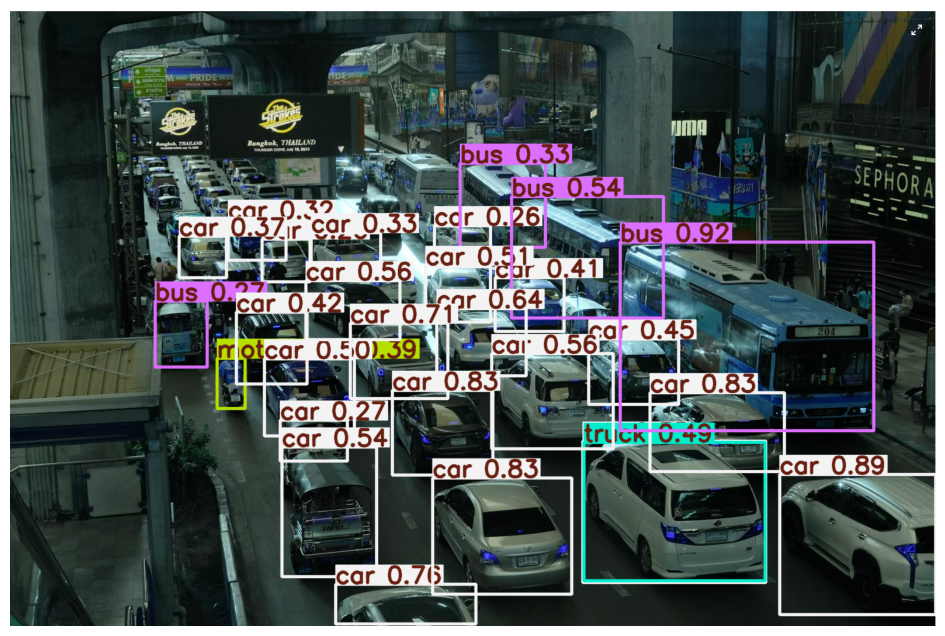

Dense Caption: In this bustling street scene, a sturdy bus dominates the foreground at coordinates (1044, 397, 1478, 720), its bright colors contrasting against the surrounding vehicles. Nearby, a sleek car is stationed at (1317, 795, 1584, 1035), while another compact car sits at (723, 801, 961, 1000), both adding to the urban tapestry. Just a little farther up, a mid-sized car occupies the space at (1095, 655, 1325, 790), alongside another vehicle positioned at (654, 651, 826, 796).

Navigating the scene, an array of cars like the one at (557, 983, 797, 1051) and the vibrant vehicle at (582, 536, 749, 665) effortlessly blend in with the rhythm of the city. The line of automobiles continues with a car at (730, 511, 883, 626) and a further addition at (824, 588, 1032, 751).

Nearby, a truck waits patiently at (982, 740, 1292, 977), its imposing structure juxtaposing the multitude of smaller vehicles. The flux of cars does not cease, as the sleek presence of a car at (990, 563, 1144, 67

In [21]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Load YOLOv8 model (Nano or Extra-Large)
model = YOLO("yolov8n.pt")  # or "yolov8x.pt"

# Run detection
results = model("denseimage.jpg")

# Get the first result (since results is a list)
annotated_img = results[0].plot()  # returns numpy array with boxes drawn

# Show inline with matplotlib
plt.figure(figsize=(12,8))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()



detections = []
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    label = model.names[cls_id]
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    detections.append(f"{label} at ({int(x1)},{int(y1)},{int(x2)},{int(y2)})")

detections_str = "Objects detected: " + ", ".join(detections)
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are a dense captioning agent. Generate a richly descriptive caption based on detected objects and their positions."},
        {"role": "user", "content": detections_str}
    ]
)

print("Dense Caption:", response.choices[0].message.content)
